In [3]:
from google.colab import drive

In [2]:
# Import libraries used for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for better looking charts
sns.set(style="whitegrid")

In [12]:
df = pd.read_csv('/content/drive/MyDrive/DataAnaysis/superstore.csv')

# Display first rows to understand the dataset structure
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
df.shape

(51290, 27)

In [7]:

# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [8]:
# Summary statistics of numerical columns
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [13]:
# Rename columns to clean format
df.columns = df.columns.str.replace('.', '_', regex=False)

# Check columns after renaming
print(df.columns)

Index(['Category', 'City', 'Country', 'Customer_ID', 'Customer_Name',
       'Discount', 'Market', '记录数', 'Order_Date', 'Order_ID', 'Order_Priority',
       'Product_ID', 'Product_Name', 'Profit', 'Quantity', 'Region', 'Row_ID',
       'Sales', 'Segment', 'Ship_Date', 'Ship_Mode', 'Shipping_Cost', 'State',
       'Sub_Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')


In [14]:
df = df.drop(columns=['记录数'])

In [16]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
df = df.drop_duplicates()

# check missing values
print(df.isnull().sum())

Category          0
City              0
Country           0
Customer_ID       0
Customer_Name     0
Discount          0
Market            0
Order_Date        0
Order_ID          0
Order_Priority    0
Product_ID        0
Product_Name      0
Profit            0
Quantity          0
Region            0
Row_ID            0
Sales             0
Segment           0
Ship_Date         0
Ship_Mode         0
Shipping_Cost     0
State             0
Sub_Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [21]:
#Create time-based features

In [20]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Week'] = df['Order_Date'].dt.isocalendar().week
df['Day'] = df['Order_Date'].dt.day

In [22]:
# Calculate shipping delay in days
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# Profit ratio (Profit / Sales)
df['Profit_Ratio'] = df['Profit'] / df['Sales']


In [23]:
print(df[['Order_Date','Ship_Date','Year','Month','Week','Day','Shipping_Days','Profit_Ratio']].head())

  Order_Date  Ship_Date  Year  Month  Week  Day  Shipping_Days  Profit_Ratio
0 2011-01-07 2011-01-09  2011      1     1    7              2      0.491116
1 2011-01-21 2011-01-26  2011      1     3   21              5      0.489095
2 2011-08-05 2011-08-09  2011      8    31    5              4      0.468657
3 2011-08-05 2011-08-09  2011      8    31    5              4      0.479827
4 2011-09-29 2011-10-03  2011      9    39   29              4      0.518400


In [24]:
total_sales = df['Sales'].sum()
avg_sales = df['Sales'].mean()
max_sales = df['Sales'].max()
min_sales = df['Sales'].min()

print(f"Total Sales: {total_sales}")
print(f"Average Sale: {avg_sales}")
print(f"Max Sale: {max_sales}, Min Sale: {min_sales}")


Total Sales: 12642905
Average Sale: 246.49844024176252
Max Sale: 22638, Min Sale: 0


In [26]:
#Top 10 Stores by sales
top_stores = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
print("Top 10 Cities by Sales:\n", top_stores.head(10))


Top 10 Cities by Sales:
 City
New York City    256397
Los Angeles      175857
Manila           120896
Seattle          119552
San Francisco    112690
Philadelphia     109085
Sydney           101952
Jakarta           94318
London            86945
Mexico City       85732
Name: Sales, dtype: int64


In [27]:
# Top 10 Products by sales
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)
print("Top 10 Products by Sales:\n", top_products.head(10))


Top 10 Products by Sales:
 Product_Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64


In [28]:
# Top 10 Customers by sales
top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False)
print("Top 10 Customers by Sales:\n", top_customers.head(10))

Top 10 Customers by Sales:
 Customer_ID
SM-203204    25042
TC-209804    19050
CS-118451    16655
SP-209202    16566
VG-218051    15654
RB-193604    15117
PF-191201    15063
TA-213854    14596
BF-110051    14563
AB-101054    14476
Name: Sales, dtype: int64


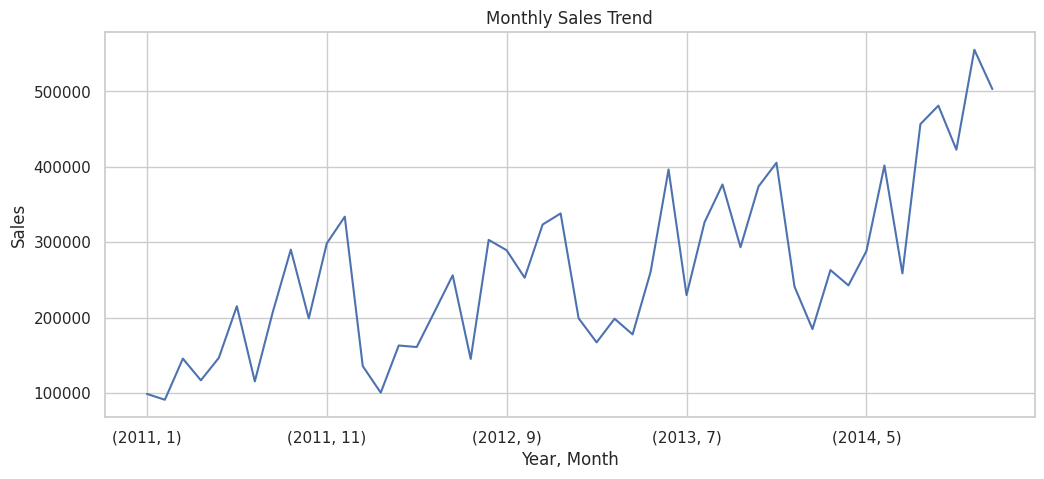

In [30]:
# Monthly sales trend
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum()
monthly_sales.plot(kind='line', figsize=(12,5), title="Monthly Sales Trend")
plt.xlabel("Year, Month")
plt.ylabel("Sales")
plt.show()




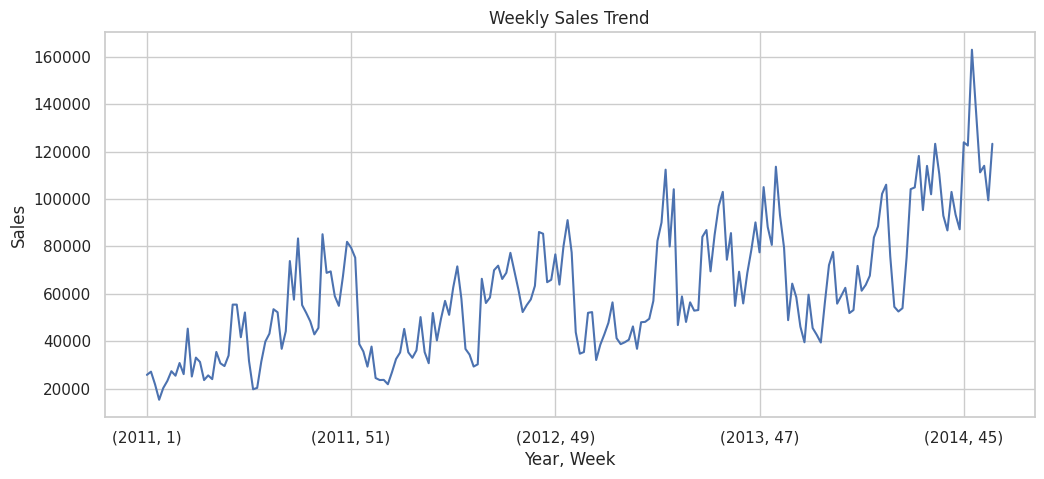

In [31]:
# Weekly sales trend
weekly_sales = df.groupby(['Year','Week'])['Sales'].sum()
weekly_sales.plot(kind='line', figsize=(12,5), title="Weekly Sales Trend")
plt.xlabel("Year, Week")
plt.ylabel("Sales")
plt.show()

In [32]:
# Average shipping delay
avg_shipping_days = df['Shipping_Days'].mean()
print(f"Average Shipping Delay (days): {avg_shipping_days:.2f}")

Average Shipping Delay (days): 3.97


In [35]:
# Average profit ratio
avg_profit_ratio = df['Profit_Ratio'].mean()
print(f"Average Profit Ratio: {avg_profit_ratio:.2f}")

Average Profit Ratio: -inf


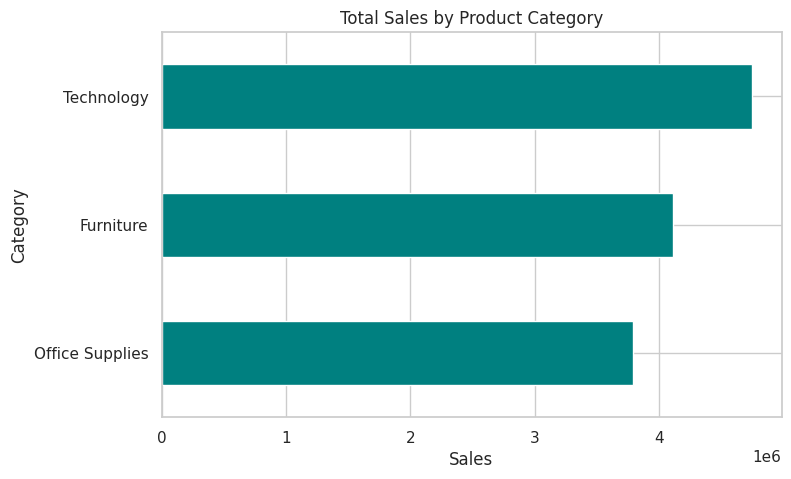

In [36]:
# 9.1 Total Sales by Product Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
category_sales.plot(kind='barh', color='teal')
plt.title("Total Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.show()

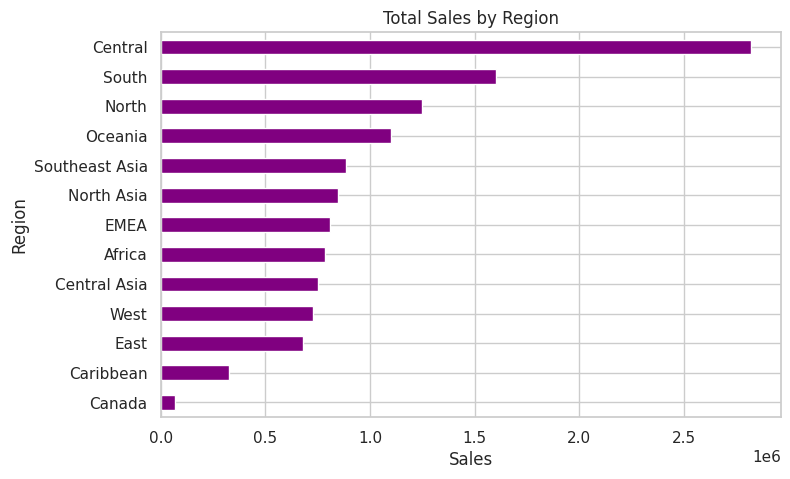

In [37]:
# 9.2 Total Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
region_sales.plot(kind='barh', color='purple')
plt.title("Total Sales by Region")
plt.xlabel("Sales")
plt.ylabel("Region")
plt.show()

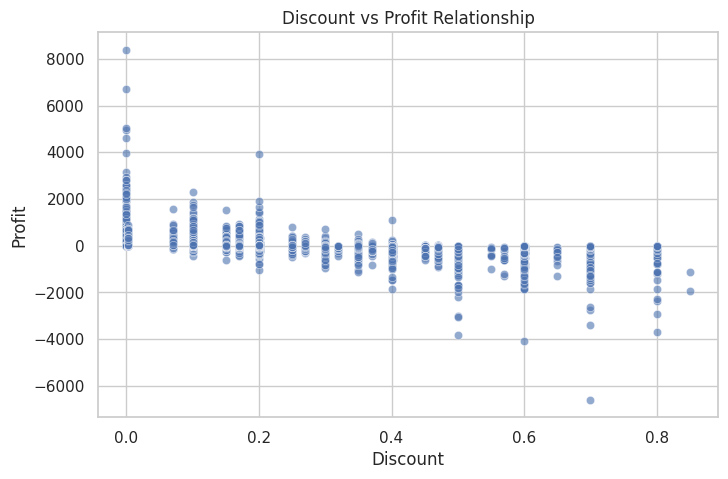

In [38]:
# 9.3 Discount vs Profit Scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

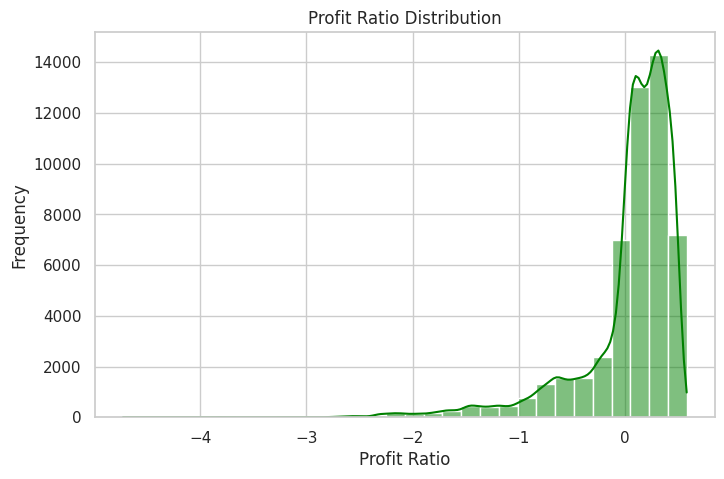

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit_Ratio'], bins=30, kde=True, color='green')
plt.title("Profit Ratio Distribution")
plt.xlabel("Profit Ratio")
plt.ylabel("Frequency")
plt.show()

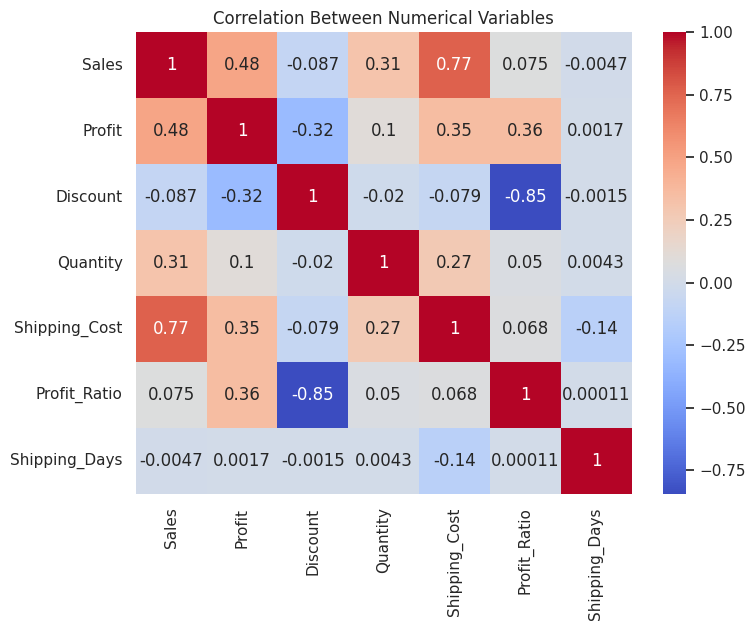

In [40]:
numeric_cols = ['Sales','Profit','Discount','Quantity','Shipping_Cost','Profit_Ratio','Shipping_Days']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Variables")
plt.show()

In [41]:
df.to_csv('/content/drive/MyDrive/DataAnaysis/Global_Superstore_Cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
